run this headless

conda activate guitarmidi
screen jupyter nbconvert --to notebook --execute traning.ipynb --output=output_notebook.ipynb --ExecutePreprocessor.timeout=-1



In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.callbacks import ReduceLROnPlateau
# NO Keras backend import needed now

import common
from common import INPUT_SHAPE, OUTPUT_DIM_NOTES
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import os
import glob # To list files
import random
input_data_dir = '/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/data_slices'#'/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/data_slices/training'
input_filepaths = sorted(glob.glob(os.path.join(input_data_dir, '**', 'input', 'data.tfrecord'), recursive=True))
random.seed(42)
random.shuffle(input_filepaths)

print("selected files: input: ",len(input_filepaths))

I0000 00:00:1770206732.639173  861830 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1770206732.666298  861830 cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1770206733.181495  861830 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
W0000 00:00:1770206733.814648  861830 gpu_device.cc:2456] TensorFlow was not built with CUDA kernel bi

Filter mask created with shape: (312, 129)
selected files: input:  10135


Model Architecture:
--------------------------------------------------------------------------------
Model: "functional"
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (1024, 312, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (1024, 312, 256,  │          0 │ input_layer[0][0] │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (1024, 312, 32,   │        272 │ reshape[0][0]     │
│                     │ 16)               │            │                   │
├─────────────────────┼─────────

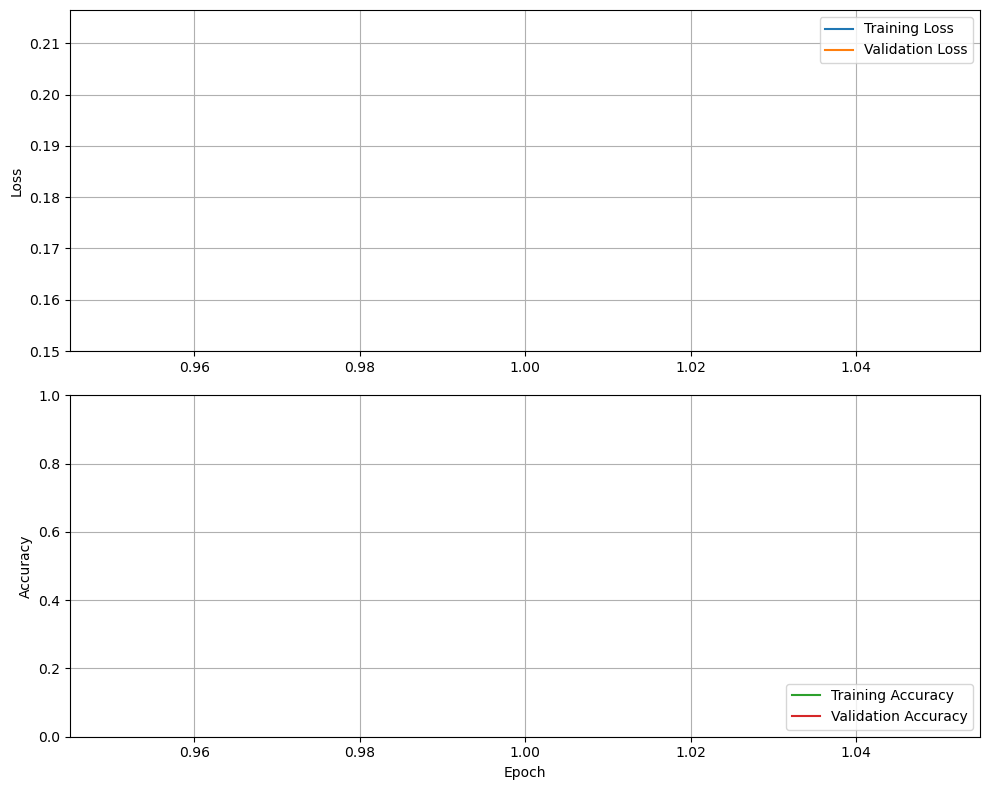

1075/1075 ━━━━━━━━━━━━━━━━━━━━ 322s 290ms/step - accuracy: 0.1293 - loss: 0.1530 - precision: 0.2691 - recall: 0.5752 - val_accuracy: 0.0330 - val_loss: 0.2135 - val_precision: 0.0954 - val_recall: 0.0497 - learning_rate: 0.0010
Epoch 2/100
   1/1075 ━━━━━━━━━━━━━━━━━━━━ 35s 33ms/step - accuracy: 0.1543 - loss: 0.1174 - precision: 0.1918 - recall: 0.0985

I0000 00:00:1770207056.552965  862103 local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
I0000 00:00:1770207056.552990  862103 local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
	 [[IteratorGetNext/_4]]
I0000 00:00:1770207056.552993  862103 local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 16204695350201500021
I0000 00:00:1770207056.552998  862103 local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 6317888991789852968
/home/gerald/anaconda3/envs/gpu/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


KeyboardInterrupt: 

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.callbacks import ReduceLROnPlateau
# NO Keras backend import needed now
from model import build_1d_cnn_model # Assumes build_cnn_model is in model.py
import common
from common import INPUT_SHAPE, OUTPUT_DIM_NOTES,fast_gpu_map,SAMPLERATE,feature_description,INPUT_SHAPE_AUDIO
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import os
import glob # To list files
import datetime
from fretboard import FretBoard
from scipy import signal
# --- 1. GPU Setup ---
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Enable Mixed Precision
        tf.keras.mixed_precision.set_global_policy('mixed_float16')
        print("Mixed precision policy set to 'mixed_float16'.")

        for gpu in gpus:
            # Enable memory growth
            tf.config.experimental.set_memory_growth(gpu, True)
        print("Memory growth enabled for GPUs.")
    except RuntimeError as e:
        print(f"Error configuring GPU: {e}")
# ---------------------------------------------------------------------------------

print(f"TensorFlow version: {tf.__version__}")

# --- 2. Configuration ---
LEARNING_RATE = 0.001
BATCH_SIZE = 1024
EPOCHS = 100
print("Batch size:",BATCH_SIZE)
print("Learning rate:",LEARNING_RATE)
print("Epochs:",EPOCHS)
SAMPLES=504000000000/(312*256*4+129) # Rough estimate of total samples in dataset
print("Estimated total samples:",SAMPLES)
STEPS_PER_EPOCH = int(SAMPLES // BATCH_SIZE)
print("Steps per epoch:",STEPS_PER_EPOCH)
VALIDATION_STEPS = 2000
train_with_mapping = True  # Set to True to use mapped loading, False for interleaved
split_ratio = 0.7


# --- 3. Model Definition ---
cnn_model = build_1d_cnn_model(BATCH_SIZE,common.INPUT_SHAPE, common.OUTPUT_DIM_NOTES)
# cnn_model.compile(optimizer=optimizers.Adam(learning_rate=LEARNING_RATE,clipnorm=1.0), # <-- ADDED CLIPNORM
#                   loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.1),
#                   metrics=['accuracy',
#                         tf.keras.metrics.Precision(name='precision'), 
#                         tf.keras.metrics.Recall(name='recall')
#                         ],
#                     jit_compile=True)
def weighted_bce_loss(y_true, y_pred):
    # 5.0 means 'Missing a note is 5x worse than a false alarm'
    pos_weight = 5.0
    
    # Clip predictions for numerical stability
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
    
    # Weighted Binary Crossentropy math
    loss = - (pos_weight * y_true * tf.math.log(y_pred) + (1.0 - y_true) * tf.math.log(1.0 - y_pred))
    return tf.reduce_mean(loss)

# Compile with the new loss
cnn_model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001, clipnorm=1.0),
    loss=weighted_bce_loss,
    metrics=['accuracy', tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')],
    jit_compile=True
)
cnn_model.summary()


# --- 4. Custom Callback for Real-Time Plotting and Model Summary ---
class PlotLoss(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.losses = []
        self.val_losses = []
        self.acc = []
        self.val_acc = []
        self.epochs_run = []
        self.fig, (self.ax_loss, self.ax_acc) = plt.subplots(2, 1, figsize=(10, 8))
            # Save model summary to string
        summary_list = []
        self.model.summary(print_fn=lambda x: summary_list.append(x))
        self.model_summary = '\n'.join(summary_list)
        
        # Save summary to file
        with open('model_summary.txt', 'w') as f:
            f.write(self.model_summary)

    def on_epoch_end(self, epoch, logs=None):
        # local import so notebook output display works even when executed headless
        from IPython.display import display, Image, clear_output

        logs = logs or {}
        self.epochs_run.append(epoch + 1)

        # safe conversion to numbers (use NaN if missing)
        self.losses.append(float(logs.get('loss')) if logs.get('loss') is not None else np.nan)
        self.val_losses.append(float(logs.get('val_loss')) if logs.get('val_loss') is not None else np.nan)

        # support both 'accuracy' and 'acc' keys
        acc_val = logs.get('accuracy') if 'accuracy' in logs else logs.get('acc')
        val_acc_val = logs.get('val_accuracy') if 'val_accuracy' in logs else logs.get('val_acc')
        self.acc.append(float(acc_val) if acc_val is not None else np.nan)
        self.val_acc.append(float(val_acc_val) if val_acc_val is not None else np.nan)

        # clear previous cell output, draw and save figure, then display saved PNG so it remains in notebook
        clear_output(wait=True)
        # Print model summary first
        print("Model Architecture:")
        print("-" * 80)
        print(self.model_summary)
        print("-" * 80)
        #print(f"\nTraining Progress - Epoch {epoch + 1}/{self.model.epochs}")

        # Loss subplot
        self.ax_loss.clear()
        self.ax_loss.plot(self.epochs_run, self.losses, label='Training Loss', color='tab:blue')
        if any(~np.isnan(self.val_losses)):
            self.ax_loss.plot(self.epochs_run[:len(self.val_losses)], self.val_losses, label='Validation Loss', color='tab:orange')
        self.ax_loss.set_ylabel('Loss')
        self.ax_loss.legend(loc='upper right')
        self.ax_loss.grid(True)

        # Accuracy subplot
        self.ax_acc.clear()
        self.ax_acc.plot(self.epochs_run, self.acc, label='Training Accuracy', color='tab:green')
        if any(~np.isnan(self.val_acc)):
            self.ax_acc.plot(self.epochs_run[:len(self.val_acc)], self.val_acc, label='Validation Accuracy', color='tab:red')
        self.ax_acc.set_xlabel('Epoch')
        self.ax_acc.set_ylabel('Accuracy')
        self.ax_acc.set_ylim(0.0, 1.0)
        self.ax_acc.legend(loc='lower right')
        self.ax_acc.grid(True)

        self.fig.tight_layout()
        self.fig.savefig("training.png", bbox_inches='tight')  # persist image
        display(Image("training.png"))  # embed PNG in notebook output so it remains visible
        plt.close(self.fig)  # close to free memory; will recreate on next epoch

# --- 5. Data Loading with tf.data and Sample Weights ---

total_samples_on_disk = len(input_filepaths)


print(f"Found {total_samples_on_disk} files on disk.")



# Split dataset into training and validation sets


split_idx = int(SAMPLES * split_ratio)


# --- 6. Dataset Preparation (Mapped vs Interleaved Loading) ---


if train_with_mapping:
    print("Using mapped dataset loading.")
    dataset=tf.data.TFRecordDataset(input_filepaths).shuffle(buffer_size=total_samples_on_disk)
    print("Dataset created from TFRecord files.")
    # print("Total records in dataset:",len(list(dataset)))
    train_files = dataset.take(split_idx)

    val_files = dataset.skip(split_idx)    
else:
    print("Using interleaved dataset loading.")
    dataset=tf.data.Dataset.from_tensor_slices(input_filepaths).shuffle(buffer_size=total_samples_on_disk)
    train_files=dataset.take(split_idx)
    val_files=dataset.skip(split_idx)

# Define a function to load and preprocess data from TFRecord files. Used for interleaved loading.
def map_func(input_path,training=True):
    # 1. Load the raw TFRecord
    ds = tf.data.TFRecordDataset(input_path, num_parallel_reads=tf.data.AUTOTUNE)
    
    # 2. Parse the record into (features, labels)
    ds = ds.map(lambda path: fast_gpu_map(path, training=training), num_parallel_calls=tf.data.AUTOTUNE)
    


    return ds


# Map loading function (now includes the weight vector)
if train_with_mapping:
    train_dataset = train_files.shuffle(BATCH_SIZE * 2).map(lambda path: fast_gpu_map(path, training=True), num_parallel_calls=tf.data.AUTOTUNE)
    val_dataset = val_files.shuffle(BATCH_SIZE * 2).map(lambda path: fast_gpu_map(path, training=False), num_parallel_calls=tf.data.AUTOTUNE)
else:
    # Increase the number of parallel workers to overwhelm the bottleneck
    train_dataset = train_files.interleave(
        lambda path: map_func(path, training=True),
        cycle_length=32,          # Open 32 files at once
        block_length=16,        # Read 16 samples from each file before switching
        num_parallel_calls=tf.data.AUTOTUNE,
        deterministic=False       # Essential for speed
    )


    val_dataset = val_files.interleave(
        lambda path: map_func(path, training=False),
        cycle_length=32,          # Open 32 files at once
        block_length=16,        # Read 16 samples from each file before switching
        num_parallel_calls=tf.data.AUTOTUNE,
        deterministic=False       # Essential for speed
    )



# Apply batching and prefetching  (use train/val_dataset.cache().batch... if needed)
train_dataset = train_dataset.shuffle(BATCH_SIZE * 4).batch(BATCH_SIZE,drop_remainder=True).prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.shuffle(BATCH_SIZE * 4).batch(BATCH_SIZE,drop_remainder=True).prefetch(tf.data.AUTOTUNE)
# --- 6. Callbacks ---

plot_callback = PlotLoss()
early_stopping_callback = EarlyStopping(
    monitor='val_loss', 
    patience=5,   
    min_delta=0.0001, 
    mode='min',          
    verbose=1,           
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_lr=1e-6,
    verbose=1
)
checkpoint=ModelCheckpoint('checkpoints/guitarmidi_epoch{epoch:02d}_valAcc{val_accuracy:.4f}.weights.h5', save_weights_only=True,save_freq='epoch')
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir,
        histogram_freq=1,  # Log weight histograms every epoch
        write_graph=True,
        write_images=True,
        update_freq='epoch',
        profile_batch='10,20',  # Profile batches 10-20 for performance analysis
        embeddings_freq=1)


print("\n--- Starting CNN Model Training with Sample Weights ---")
try:
    
    history_cnn = cnn_model.fit(train_dataset,
                                #initial_epoch=31,
                                epochs=EPOCHS,
                                steps_per_epoch=STEPS_PER_EPOCH,
                                validation_steps=VALIDATION_STEPS,
                                #batch_size=BATCH_SIZE, shuffle=False,
                                validation_data=val_dataset,
                                callbacks=[plot_callback, early_stopping_callback,checkpoint,reduce_lr,tensorboard_callback])
    
    cnn_model.save_weights('guitarmidi.weights.h5')
    print("Model weights saved successfully!")
    
except Exception as e:
    print(f"An error occurred during training: {e}")

In [ ]:
from tensorflow.data import Dataset
dataset = Dataset.range(1, 6)  # ==> [ 1, 2, 3, 4, 5 ]
# NOTE: New lines indicate "block" boundaries.
dataset = dataset.interleave(
  lambda x: Dataset.from_tensors(x).repeat(6),
    cycle_length=2, block_length=4)
list(dataset.as_numpy_iterator())